# Reward Manipulation Effect on trial-by-trial force pattern dynamics

In [1]:
# ============================================================================
# IMPORTS, SETUP, AND EXPERIMENTAL PARAMETERS
# ============================================================================
# Data manipulation and visualization libraries
import pandas as pd              
import numpy as np             
import utils                    
import seaborn as sns      
from matplotlib import rcParams  
import matplotlib.pyplot as plt  

# Experimental parameters - Reward Manipulation Design
seq_length = 7                    # Length of trained sequence (# of finger presses)
fingers = ['1', '2', '3', '4', '5']  # Finger mapping to numeric labels
iti = 3000                        # Inter-trial interval (ms)
hand = 2                          # Hand used (2 = right hand)
total_sub_num = 11                # Number of subjects
num_trained_seq = 1               # Number of sequences trained
num_sessions = 4                  # Training sessions
num_blocks_per_session = 4        # Blocks per session
num_baseline_blocks = 1           # Baseline blocks before manipulation
num_trials_per_block = 40         # Trials per block

# Percentiles for categorizing trials by execution time (ET)
percentile_low = 45               # Low ET trials (fast)
percentile_high = 80              # High ET trials (slow)
percentile_low_super = 10         # Very fast trials

utils.set_figure_style("1col")

In [2]:
# ============================================================================
# DATA LOADING
# ============================================================================
# Load force data: trial-by-trial force profiles during sequence execution
forces = pd.read_csv('./Data/Reward_Manipulation_Forces.csv', sep='\t')

# Create force_vector column: concatenate individual force measurements into arrays
# This enables vectorized distance calculations between trials
forces['force_vector'] = forces[[col for col in forces.columns if col.startswith('force_')]].apply(lambda x: np.array(x), axis=1)

# Load subject-level data: behavioral metrics (ET, errors, reward condition, etc.)
subjs = pd.read_csv('./Data/Reward_Manipulation_Subjs.csv', sep='\t')

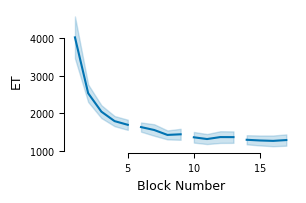

In [3]:
# Execution time (ET) over learning, excluding error trials

subjs_correct = utils.remove_error_trials(subjs)
grouped_subjs = subjs_correct.groupby(['SubNum', 'BN', 'day']).agg({'ET': 'median'}).reset_index()
for day, day_data in grouped_subjs.groupby('day'):
    sns.lineplot(data=day_data, x='BN', y='ET', errorbar = 'se', color = sns.color_palette("colorblind")[0])
plt.xlabel('Block Number')
sns.despine(trim=True)


<img src="Figs/RewardManipulationSchematic.jpg" width="500">

In [5]:
# ============================================================================
# TRIAL-BY-TRIAL FORCE PATTERN DYNAMICS
# ============================================================================
# Analyze how force patterns change from trial t to trial t+1 (neighbouring trials)
# This reveals trial-by-trial learning and the effect of reward manipulation

distances = []
for subind, subdata in forces.groupby('SubNum'):
    for zone, zonedata in subdata.groupby('zone'):
        # Loop through points (ET-based trial categories)
        for point, pointdata in zonedata.groupby('points'):
            for i in range(len(pointdata)):
                row = pointdata.iloc[i]
                N = row['N']                               # Current trial number
                next_trial = subdata[subdata['N'] == N + 1]  # Find next trial
                
                # Only analyze if next trial exists and is in the same block
                if not next_trial.empty and (next_trial.iloc[0]['BN'] == row['BN']):
                    next_row = next_trial.iloc[0]
                    
                    # Calculate Euclidean distance between consecutive force patterns
                    force_vector_1 = row['force_vector']
                    force_vector_2 = next_row['force_vector']
                    euclidean_distance = np.linalg.norm(force_vector_1 - force_vector_2)
                    
                    distances.append({
                        'SubNum': subind,
                        'points': point,                    # ET percentile category
                        'zone': row['zone'],                # ET zone
                        'distance': euclidean_distance,     # ||F_{t+1} - F_t||
                        'BN': row['BN'],                    # Block number
                        'day': row['day'],
                        'ET': row['ET'],
                        'force': row['force_vector'],
                    })

distances = pd.DataFrame(distances)    
distances['count'] = 1

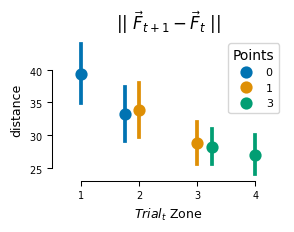

In [6]:
# exclude first three blocks
distances = distances[distances['BN'] > 3]
distances = distances[distances['zone'] != 0]
grouped_distances = distances.groupby(['SubNum', 'points', 'zone']).agg({'distance': 'median',
                                                                         'count': 'count'}).reset_index()

non_manipulated_zones = [0,1,4]
manipulated_zones = [2,3]
non_manipulated_grouped = grouped_distances.copy()
# set rows with zones 2 and 3 to NaN
non_manipulated_grouped.loc[non_manipulated_grouped['zone'].isin(manipulated_zones), 'distance'] = np.nan
sns.pointplot(data = non_manipulated_grouped, x = 'zone', y = 'distance', errorbar='se', linestyles='', legend=False, hue = 'points', palette='colorblind')

manipulated_grouped = grouped_distances[grouped_distances['zone'].isin(manipulated_zones)]
sns.pointplot(data = manipulated_grouped, x = 'zone', y = 'distance', errorbar='se', linestyles='', hue = 'points', palette = 'colorblind', dodge = 0.5)

plt.xlabel(r'$Trial_t$ Zone')
plt.title(r'|| $\vec{F}_{t+1} - \vec{F}_{t}$ ||')
plt.legend(loc = 'upper right', title = 'Points', bbox_to_anchor=(1, 1))
sns.despine(trim=True)

    

In [7]:
# calculating the cosine similarity between the force vectors of trial t and trial t+1

cosines = []
for subind, subdata in forces.groupby('SubNum'):
    for zone, zonedata in subdata.groupby('zone'):
        for point, pointdata in zonedata.groupby('points'):
            for i in range(len(pointdata)):
                row = pointdata.iloc[i]
                N = row['N']
                next_trial = subdata[subdata['N'] == N + 1]
                if not next_trial.empty:
                    next_row = next_trial.iloc[0]
                    # compute cosine similarity 
                    force_vector_1 = row['force_vector']
                    force_vector_2 = next_row['force_vector']
                    cosine_similarity = np.dot(force_vector_1, force_vector_2) / \
                    (np.linalg.norm(force_vector_1) * np.linalg.norm(force_vector_2))
                    # append to the cosines list
                    cosines.append({
                        'SubNum': subind,
                        'points': point,
                        'zone': row['zone'],
                        'cosine_similarity': cosine_similarity,
                        'BN': row['BN'],
                        'day': row['day']
                    })



cosines = pd.DataFrame(cosines)
        
cosines['count'] = 1

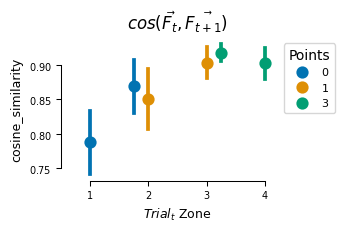

In [8]:
# exclude first three blocks
distances = distances[distances['BN'] > 3]
cosines = cosines[cosines['zone'] != 0]
grouped_cosines = cosines.groupby(['SubNum', 'points', 'zone']).agg({'cosine_similarity': 'median',
                                                                         'count': 'count'}).reset_index()

non_manipulated_zones = [0,1,4]
manipulated_zones = [2,3]
non_manipulated_grouped = grouped_cosines.copy()
# set rows with zones 2 and 3 to NaN
non_manipulated_grouped.loc[non_manipulated_grouped['zone'].isin(manipulated_zones), 'cosine_similarity'] = np.nan
sns.pointplot(data = non_manipulated_grouped, x = 'zone', y = 'cosine_similarity', errorbar='se', linestyles='', legend=False, hue = 'points', palette='colorblind')


manipulated_grouped = grouped_cosines[grouped_cosines['zone'].isin(manipulated_zones)]
sns.pointplot(data = manipulated_grouped, x = 'zone', y = 'cosine_similarity', errorbar='se', linestyles='', hue = 'points', palette = 'colorblind', dodge = 0.5)

plt.xlabel(r'$Trial_t$ Zone')
plt.title(r'$cos (\vec{F_t}, \vec{F_{t+1}})$')
plt.legend(loc = 'upper right', title = 'Points', bbox_to_anchor=(1.2, 1))
sns.despine(trim=True)
    

In [9]:
# calculating the ET of trial t+1 for each trial t

next_ETs = []
forces_wide_correct = forces
for subind, subdata in forces_wide_correct.groupby('SubNum'):
    for zone, zonedata in subdata.groupby('zone'):
        for point, pointdata in zonedata.groupby('points'):
            # loop through all the points in pointdata
            for i in range(len(pointdata)):
                row = pointdata.iloc[i]
                N = row['N']
                next_trial = subdata[subdata['N'] == N + 1]
                if not next_trial.empty and (next_trial.iloc[0]['BN'] == row['BN']):  # Ensure next trial is in the same block
                    next_row = next_trial.iloc[0]
                    # append to the next_ETs list
                    next_ETs.append({
                        'SubNum': subind,
                        'points': point,
                        'zone': row['zone'],
                        'ET':  next_row['ET'],
                        'BN': row['BN']
                    })

next_ETs = pd.DataFrame(next_ETs)
        
next_ETs['count'] = 1

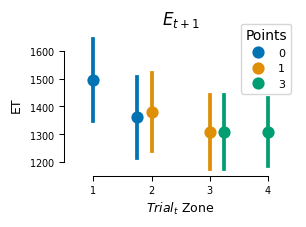

In [10]:
next_ETs = next_ETs[next_ETs['BN'] > 5]  # Exclude first day blocks
next_ETs = next_ETs[next_ETs['zone'] != 0]

grouped_speeds = next_ETs.groupby(['SubNum', 'zone', 'points']).agg({'ET': 'median'}).reset_index()

non_manipulated_zones = [0,1,4]
manipulated_zones = [2,3]
non_manipulated_grouped = grouped_speeds.copy()
# set rows with zones 2 and 3 to NaN
non_manipulated_grouped.loc[non_manipulated_grouped['zone'].isin(manipulated_zones), 'ET'] = np.nan
sns.pointplot(data = non_manipulated_grouped, x = 'zone', y = 'ET', errorbar='se', linestyles='', legend=False, hue = 'points', palette='colorblind')

manipulated_grouped = grouped_speeds[grouped_speeds['zone'].isin(manipulated_zones)]
sns.pointplot(data = manipulated_grouped, x = 'zone', y = 'ET', errorbar='se', linestyles='', hue = 'points', palette = 'colorblind', dodge = 0.5)

plt.xlabel(r'$Trial_t$ Zone')
plt.title(r'$E_{t+1}$')
plt.legend(loc='upper right', title = 'Points', bbox_to_anchor=(1, 1.1))

sns.despine(trim=True)


